# The PDSA Loop made queryable

In [2]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))
from src.db import get_connection

con = get_connection(read_only=True)
print("Connection Established :)") 

Connection Established :)


In [3]:
# ── Intervention Target Parameters ───────────────────────────────────────
# Adjust these to model different scenarios.
# Each pair represents (current_state, intervention_target).

# Radiology — prior auth obtain rate
RADIOLOGY_AUTH_CURRENT = 0.68
RADIOLOGY_AUTH_TARGET  = 0.85

# Internal Medicine — timely filing miss rate (% of claims breaching window)
IM_FILING_MISS_CURRENT = 0.07
IM_FILING_MISS_TARGET  = 0.02   # residual — some late captures are unavoidable

# Emergency — coding accuracy rate
EMERGENCY_CODING_CURRENT = 0.78
EMERGENCY_CODING_TARGET  = 0.90

# Behavioral Health — credentialing lapse rate
BH_CRED_LAPSE_CURRENT = 0.12
BH_CRED_LAPSE_TARGET  = 0.03

RECOVERY_THRESHOLD   = 150_000   # dollars recovered above which an intervention is "high-value"
COMPLEXITY_THRESHOLD = 2.5        # midpoint of the 1=easy → 5=hard scale

# ── Implementation Complexity Proxy (1=easy → 5=hard) ────────────────────
# Used for prioritization matrix. Adjust based on your org's capacity.
COMPLEXITY = {
    "Auth Workflow (CO-57)":       2,   # scheduling checklist, staff training
    "Charge Lag Process (CO-29)":  3,   # billing culture change, EMR workflow
    "Coding Accuracy (CO-4)":      3,   # coder education + CDI program
    "Credentialing Renewal (CO-B7)": 1, # calendar alerts, re-credentialing tracker
}

print("Parameters loaded. Adjust variables above to model different scenarios.")

Parameters loaded. Adjust variables above to model different scenarios.


------
#### Chapter 1 · Failure Node Baseline

###### Question: What is the current dollar exposure by upstream failure node?

###### Before modeling any intervention, establish what each failure node costs. This is the number the intervention has to beat.

In [4]:
baseline = con.execute("""
    SELECT
        df.upstream_failure_node,
        df.denial_category,
        df.carc_code,
        COUNT(*)                            AS denial_count,
        ROUND(SUM(df.dollars_at_risk), 2)   AS total_dollars_at_risk,
        ROUND(AVG(df.dollars_at_risk), 2)   AS avg_denial_amount,
        ROUND(AVG(df.recovery_probability), 3) AS avg_recovery_prob,
        ROUND(SUM(df.dollars_at_risk * df.recovery_probability), 2) AS expected_recoverable
    FROM denial_forensics df
    GROUP BY df.upstream_failure_node, df.denial_category, df.carc_code
    ORDER BY total_dollars_at_risk DESC
""").df()

print("Denial Baseline by Failure Node\n")
print(baseline.to_string(index=False))

Denial Baseline by Failure Node

upstream_failure_node          denial_category carc_code  denial_count  total_dollars_at_risk  avg_denial_amount  avg_recovery_prob  expected_recoverable
               coding             coding_error      CO-4          3276             3981335.76            1215.30               0.70            2786935.03
  prior_authorization            authorization     CO-57          1281             2986941.52            2331.73               0.55            1642817.84
  prior_authorization        medical_necessity     CO-50           759             1903690.02            2508.16               0.35             666291.51
              billing      missing_information     CO-16          1591             1680743.15            1056.41               0.72            1210135.07
               coding                 bundling     CO-97           634              836811.06            1319.89               0.65             543927.19
   remittance_posting coordination_of_benef

In [5]:
modeled_carcs = {
    'CO-57': 'Auth Workflow (Ch.3)',
    'CO-29': 'Charge Lag Process (Ch.3)',
    'CO-4':  'Coding Accuracy (Ch.3)',
    'CO-B7': 'Credentialing Renewal (Ch.3)',
}

baseline_scope = baseline.copy()
baseline_scope["intervention_modeled"] = baseline_scope["carc_code"].map(modeled_carcs).fillna("— not modeled —")

total_at_risk   = baseline_scope["total_dollars_at_risk"].sum()
modeled_at_risk = baseline_scope.loc[baseline_scope["carc_code"].isin(modeled_carcs), "total_dollars_at_risk"].sum()

print("Failure Node Baseline — Scope of This Notebook\n")
print(baseline_scope[["carc_code", "denial_category", "total_dollars_at_risk", "intervention_modeled"]]
      .to_string(index=False))

print(f"\nTotal dollars at risk (all 8 failure nodes): ${total_at_risk:,.2f}")
print(f"Addressed by interventions modeled below:    ${modeled_at_risk:,.2f} "
      f"({modeled_at_risk/total_at_risk:.1%})")
print(f"Not modeled in this notebook:                ${total_at_risk - modeled_at_risk:,.2f} "
      f"({1 - modeled_at_risk/total_at_risk:.1%})")

Failure Node Baseline — Scope of This Notebook

carc_code          denial_category  total_dollars_at_risk         intervention_modeled
     CO-4             coding_error             3981335.76       Coding Accuracy (Ch.3)
    CO-57            authorization             2986941.52         Auth Workflow (Ch.3)
    CO-50        medical_necessity             1903690.02              — not modeled —
    CO-16      missing_information             1680743.15              — not modeled —
    CO-97                 bundling              836811.06              — not modeled —
    CO-22 coordination_of_benefits              765555.38              — not modeled —
    CO-B7   provider_credentialing              212264.86 Credentialing Renewal (Ch.3)
    CO-29            timely_filing               80433.83    Charge Lag Process (Ch.3)

Total dollars at risk (all 8 failure nodes): $12,447,775.58
Addressed by interventions modeled below:    $7,260,975.97 (58.3%)
Not modeled in this notebook:            

#### Within the scope of this project, we did not model the data to analyze these CARC codes for various reasons.
###### * CO-50 -- Requires clinical chart overviews instead of a process and process-rate diagnosis.
###### * CO-16 -- No behavioral flag exists in this dataset to model against.
###### * CO-22 -- No behavioral flag exists in this dataset to model against.
###### * CO-97 -- Needs cross-line code pair analysis, this code reflects a bundling issue, not a single rate.

-----
#### Chapter 2 · CO-57 Root Cause Sub-Classification

###### Question:** What is actually driving CO-57 — before the model runs?

###### This matters because the counterfactual in Section 3 assumes CO-57 denials are driven by auth not being obtained. If denials include cases where auth was obtained but the details didn't match (wrong procedure code, wrong date, wrong provider), the obtain-rate model will overstate recovery.
###### Sub-classify first. Then decide which intervention to target.

In [6]:
co57_subclass = con.execute("""
    SELECT
        p.practice_name,
        ch.payer_id,
        COUNT(*)                                                       AS co57_denials,
        SUM(df.dollars_at_risk)                                        AS dollars_at_risk,
        -- Sub-classification: auth not obtained vs obtained retroactively
        SUM(CASE WHEN ec.prior_auth_obtained = FALSE
                  OR ec.prior_auth_obtained IS NULL THEN 1 ELSE 0 END) AS auth_not_obtained,
        SUM(CASE WHEN ec.prior_auth_obtained = TRUE
                  AND ec.auth_request_date > ec.date_of_service
                 THEN 1 ELSE 0 END)                                    AS auth_obtained_late,
        SUM(CASE WHEN ec.prior_auth_obtained = TRUE
                  AND (ec.auth_request_date <= ec.date_of_service
                       OR ec.auth_request_date IS NULL)
                 THEN 1 ELSE 0 END)                                    AS auth_obtained_timely
    FROM denial_forensics df
    JOIN remittance_835 r  ON df.claim_line_id = r.claim_line_id
    JOIN claim_header ch   ON r.claim_id = ch.claim_id
    JOIN provider p        ON ch.provider_id = p.provider_id
    JOIN encounter_context ec ON ch.claim_id = ec.claim_id
    WHERE df.carc_code = 'CO-57'
    GROUP BY p.practice_name, ch.payer_id
    ORDER BY dollars_at_risk DESC
""").df()

print("CO-57 Root Cause Sub-Classification\n")
print(co57_subclass.to_string(index=False))

total = co57_subclass["co57_denials"].sum()
not_obtained = co57_subclass["auth_not_obtained"].sum()
late = co57_subclass["auth_obtained_late"].sum()
timely = co57_subclass["auth_obtained_timely"].sum()

print(f"\nAttribution Summary:")
print(f"  Auth not obtained:    {not_obtained:>6} ({100*not_obtained/total:.1f}%) → obtain-rate intervention")
print(f"  Auth obtained late:   {late:>6} ({100*late/total:.1f}%) → scheduling/timing intervention")
print(f"  Auth obtained timely: {timely:>6} ({100*timely/total:.1f}%) → documentation/matching issue")
print(f"\nNote: Section 3 counterfactual targets the 'auth not obtained' bucket only.")
print(f"If late/matching buckets are material, a separate intervention model is needed.")

CO-57 Root Cause Sub-Classification

  practice_name               payer_id  co57_denials  dollars_at_risk  auth_not_obtained  auth_obtained_late  auth_obtained_timely
 Oncology Group  medi_cal_managed_care           381       1645542.82              381.0                 0.0                   0.0
 Oncology Group     medicare_advantage           113        435660.33              113.0                 0.0                   0.0
 Oncology Group         commercial_ppo            89        407401.26               89.0                 0.0                   0.0
Radiology Group  medi_cal_managed_care           463        290287.80              463.0                 0.0                   0.0
Radiology Group     medicare_advantage           108         67956.40              108.0                 0.0                   0.0
 Oncology Group dual_eligible_cobpayer            17         63782.95               17.0                 0.0                   0.0
Radiology Group         commercial_ppo        

#### The question the query is asking is: of all three possible stories about why this auth failed, which one is actually happening?
#### We can see that the workflow is failing at the obtain step, not at timing or documentation matching. It confirms that 'obtain rate' level intervention is targeting the right spot here.

------

#### Let's look into the CO-4 and CO-B7 CARC codes to see if they have a specific failstates like the threefold causes for CO-57. Little spoiler, CO-4 and CO-B7 only have 1 lacking behavior while CO-57 has more ambiguity. 

In [7]:
# CO-4 / CO-B7 sub-classification 
flag_subclass = con.execute("""
    SELECT
        p.practice_name,
        df.carc_code,
        COUNT(*)                                                                     AS denial_count,
        SUM(CASE WHEN df.carc_code = 'CO-4'  AND ec.coding_accuracy_flag  = FALSE THEN 1
                 WHEN df.carc_code = 'CO-B7' AND ec.credentialing_lapsed  = TRUE  THEN 1
                 ELSE 0 END)                                                          AS flag_attributable,
        ROUND(100.0 * AVG(CASE WHEN df.carc_code = 'CO-4'  THEN CASE WHEN NOT ec.coding_accuracy_flag THEN 1 ELSE 0 END
                              WHEN df.carc_code = 'CO-B7' THEN CASE WHEN ec.credentialing_lapsed THEN 1 ELSE 0 END
                         END), 1)                                                     AS pct_attributable
    FROM denial_forensics df
    JOIN remittance_835 r     ON df.claim_line_id = r.claim_line_id
    JOIN claim_header ch      ON r.claim_id = ch.claim_id
    JOIN provider p           ON ch.provider_id = p.provider_id
    JOIN encounter_context ec ON ch.claim_id = ec.claim_id
    WHERE df.carc_code IN ('CO-4', 'CO-B7')
    GROUP BY p.practice_name, df.carc_code
""").df()

print("CO-4 / CO-B7 Root Cause Sub-Classification\n")
print(flag_subclass.to_string(index=False))

CO-4 / CO-B7 Root Cause Sub-Classification

          practice_name carc_code  denial_count  flag_attributable  pct_attributable
        Radiology Group      CO-4           257              257.0             100.0
Behavioral Health Group     CO-B7          1505             1505.0             100.0
         Oncology Group      CO-4           491              491.0             100.0
Internal Medicine Group      CO-4           451              451.0             100.0
Behavioral Health Group      CO-4           849              849.0             100.0
        Emergency Group      CO-4          1228             1228.0             100.0


#### What this query tells us is 100% of the CO-4 denials are coding accuracy problem and all the CO-B7 denials are a problem with credentialing timing.
#### CO-4 and CO-B7 have a clear solution to clearing those denials. CO-57 is more ambiguous because it pinged **'prior_authorization'** as the reason for why the denial exists. Authrization could be missing because nobody even requested it (not obtained), because it was requested after the service date (late), or because it was obtained but the procedure details didn't match (documentation/timely). 3 different workflows. Luckily, we found that all of the denials happen to be because 

In [8]:
# Retroactive auth: encounters where auth WAS obtained but after service date
# These did NOT generate CO-57 this period — but represent process fragility.
# If payer policy on retroactive auth tightens, these become denials.

retro_auth_risk = con.execute("""
    SELECT
        p.practice_name,
        COUNT(DISTINCT ec.encounter_id)                                            AS retro_auth_encounters,
        ROUND(100.0 * COUNT(DISTINCT ec.encounter_id) /
              SUM(COUNT(DISTINCT ec.encounter_id)) OVER (), 1)                     AS pct_of_total_retro,
        ROUND(AVG(date_diff('day', ec.date_of_service, ec.auth_request_date)), 1)  AS avg_days_late,
        ROUND(SUM(cl.billed_amount), 2)                                            AS latent_dollar_exposure
    FROM encounter_context ec
    JOIN claim_header ch ON ec.claim_id = ch.claim_id
    JOIN claim_line cl   ON ch.claim_id = cl.claim_id
    JOIN provider p      ON ch.provider_id = p.provider_id
    WHERE ec.prior_auth_required = TRUE
      AND ec.prior_auth_obtained = TRUE
      AND ec.auth_request_date > ec.date_of_service
    GROUP BY p.practice_name
    ORDER BY latent_dollar_exposure DESC
""").df()

print("Latent Risk — Retroactive Auth Exposure\n")
print(retro_auth_risk.to_string(index=False))

Latent Risk — Retroactive Auth Exposure

  practice_name  retro_auth_encounters  pct_of_total_retro  avg_days_late  latent_dollar_exposure
 Oncology Group                    387                44.1            7.2              4580286.93
Radiology Group                    490                55.9            7.0               905393.52


#### Through this query, we look specifically for authorization of service AFTER the service date THAT WERE NOT CO-57 denials. These are the authorizations acquired later that were not even labeled as denials.
#### We can see that there is a whole population of encounters that fit in with this. Hundreds of thousands of dollars on the table just because retro-autorization (authorization that's acquired after the service date) is allowed here.

In [9]:
param_check = con.execute("""
    SELECT
        p.practice_name,
        ROUND(100.0 * AVG(CASE WHEN ec.coding_accuracy_flag THEN 1 ELSE 0 END), 1) AS coding_accuracy_pct,
        ROUND(100.0 * AVG(CASE WHEN ec.credentialing_lapsed THEN 1 ELSE 0 END), 1) AS credentialing_lapse_pct
    FROM encounter_context ec
    JOIN provider p ON ec.provider_id = p.provider_id
    WHERE p.persona_type IN ('coding_errors', 'credentialing_errors')
    GROUP BY p.practice_name
""").df()

print("\nParameter Verification — Generation-Level Rates\n")
print(param_check.to_string(index=False))


Parameter Verification — Generation-Level Rates

          practice_name  coding_accuracy_pct  credentialing_lapse_pct
Behavioral Health Group                 84.3                     11.6
        Emergency Group                 78.5                      0.0


#### This query is a bit of a callback to the parameters set up at the beginning of this notebook. Through a query, we're able to see that the numbers for coding accuracy for 'Emergency Group' and credentialing lapse in 'Behavioral Health Group' are not arbitrary. 

#### Theoretically, for one's own use, they would just need to query their own organization's data (their EHR's coding accuracy data or their credentialing system's lapse tracking) to get these numbers and enter them into the parameters at the beginning of the notebook.

-------
#### Chapter 3 · Counterfactual Intervention Models
#### Question: If we moved rate X to Y, what would we recover?

#### Each model follows the same logic:
###### 1. Fetch the current denial baseline for that failure node
###### 2. Apply the reduction fraction derived from the parameter targets above
###### 3. Project denials avoided and dollars recovered

#### Reduction formula:`fraction_avoided = (target - current) / (headroom)`  
###### where headroom is the maximum improvable portion of the problem.

#### Adjust the variables in the setup cell to model different intervention intensities.


In [10]:
# ── CO-57 · Radiology Auth Obtain Rate ──────────────────────────────────
# Intervention: scheduling checkpoint + auth-required CPT flag at time of order
# Targets: encounters where auth was required but never obtained

co57_base = con.execute("""
    SELECT
        COUNT(*)                          AS total_co57_denials,
        ROUND(SUM(df.dollars_at_risk), 2) AS total_co57_dollars
    FROM denial_forensics df
    JOIN remittance_835 r ON df.claim_line_id = r.claim_line_id
    JOIN claim_header ch  ON r.claim_id = ch.claim_id
    JOIN provider p       ON ch.provider_id = p.provider_id
    WHERE df.carc_code = 'CO-57'
      AND p.persona_type = 'prior_auth_miss'
""").df()

co57_count   = co57_base["total_co57_denials"].iloc[0]
co57_dollars = co57_base["total_co57_dollars"].iloc[0]

# Fraction of current misses that the intervention would fix
# Logic: of all encounters that currently miss auth (32%), intervention
# moves 17pp to obtaining → 17/32 = 53.1% of CO-57 denials disappear
co57_headroom         = 1 - RADIOLOGY_AUTH_CURRENT
co57_reduction_frac   = (RADIOLOGY_AUTH_TARGET - RADIOLOGY_AUTH_CURRENT) / co57_headroom
co57_denials_avoided  = round(co57_count * co57_reduction_frac)
co57_dollars_recovered = round(co57_dollars * co57_reduction_frac, 2)

print("CO-57 · Radiology Auth Obtain Rate Intervention")
print(f"  Baseline:         {co57_count:,} denials  /  ${co57_dollars:,.2f} at risk")
print(f"  Current rate:     {RADIOLOGY_AUTH_CURRENT:.0%}  →  Target: {RADIOLOGY_AUTH_TARGET:.0%}")
print(f"  Reduction factor: {co57_reduction_frac:.1%} of current CO-57 denials eliminated")
print(f"  Denials avoided:  {co57_denials_avoided:,}")
print(f"  Dollars recovered: ${co57_dollars_recovered:,.2f}")

CO-57 · Radiology Auth Obtain Rate Intervention
  Baseline:         681 denials  /  $434,554.16 at risk
  Current rate:     68%  →  Target: 85%
  Reduction factor: 53.1% of current CO-57 denials eliminated
  Denials avoided:  362
  Dollars recovered: $230,856.90


In [11]:
# ── CO-29 · Internal Medicine Timely Filing ──────────────────────────────
# Intervention: EMR-integrated submission deadline alert + charge capture
#               escalation for encounters approaching 60-day mark
# Targets: IM claims submitted to Medi-Cal and Dual Eligible (90-day window)

co29_base = con.execute("""
    SELECT
        COUNT(*)                          AS total_co29_denials,
        ROUND(SUM(df.dollars_at_risk), 2) AS total_co29_dollars
    FROM denial_forensics df
    JOIN remittance_835 r ON df.claim_line_id = r.claim_line_id
    JOIN claim_header ch  ON r.claim_id = ch.claim_id
    JOIN provider p       ON ch.provider_id = p.provider_id
    WHERE df.carc_code = 'CO-29'
      AND p.persona_type = 'slow_charge_capture'
      AND ch.payer_id IN ('medi_cal_managed_care', 'dual_eligible_cobpayer')
""").df()

co29_count   = co29_base["total_co29_denials"].iloc[0]
co29_dollars = co29_base["total_co29_dollars"].iloc[0]

# Fraction of filing misses eliminated
# Logic: intervention moves miss rate from 7% to 2% — a 71.4% reduction
# in the volume of window-breaching claims
co29_reduction_frac    = (IM_FILING_MISS_CURRENT - IM_FILING_MISS_TARGET) / IM_FILING_MISS_CURRENT
co29_denials_avoided   = round(co29_count * co29_reduction_frac)
co29_dollars_recovered = round(co29_dollars * co29_reduction_frac, 2)

print("CO-29 · Internal Medicine Timely Filing Intervention")
print(f"  Baseline:          {co29_count:,} denials  /  ${co29_dollars:,.2f} at risk")
print(f"  Current miss rate: {IM_FILING_MISS_CURRENT:.0%}  →  Target: {IM_FILING_MISS_TARGET:.0%}")
print(f"  Reduction factor:  {co29_reduction_frac:.1%} of current CO-29 denials eliminated")
print(f"  Denials avoided:   {co29_denials_avoided:,}")
print(f"  Dollars recovered: ${co29_dollars_recovered:,.2f}")
print(f"\n  Note: CO-29 recovery probability is 0.10 — these dollars are largely unrecoverable")
print(f"  once the window closes. The value of this intervention is PREVENTION, not recovery.")

CO-29 · Internal Medicine Timely Filing Intervention
  Baseline:          448 denials  /  $80,433.83 at risk
  Current miss rate: 7%  →  Target: 2%
  Reduction factor:  71.4% of current CO-29 denials eliminated
  Denials avoided:   320
  Dollars recovered: $57,452.74

  Note: CO-29 recovery probability is 0.10 — these dollars are largely unrecoverable
  once the window closes. The value of this intervention is PREVENTION, not recovery.


In [12]:
# ── CO-4 · Emergency Coding Accuracy ────────────────────────────────────
# Intervention: coder education program + clinical documentation improvement (CDI)
# Targets: ER claims denied for coding errors

co4_base = con.execute("""
    SELECT
        COUNT(*)                          AS total_co4_denials,
        ROUND(SUM(df.dollars_at_risk), 2) AS total_co4_dollars
    FROM denial_forensics df
    JOIN remittance_835 r ON df.claim_line_id = r.claim_line_id
    JOIN claim_header ch  ON r.claim_id = ch.claim_id
    JOIN provider p       ON ch.provider_id = p.provider_id
    WHERE df.carc_code = 'CO-4'
      AND p.persona_type = 'coding_errors'
""").df()

co4_count   = co4_base["total_co4_denials"].iloc[0]
co4_dollars = co4_base["total_co4_dollars"].iloc[0]

# Fraction of coding errors eliminated
# Logic: current inaccuracy = 22%, target inaccuracy = 10%
# (22 - 10) / 22 = 54.5% of inaccurate encounters corrected
co4_reduction_frac    = (EMERGENCY_CODING_TARGET - EMERGENCY_CODING_CURRENT) / (1 - EMERGENCY_CODING_CURRENT)
co4_denials_avoided   = round(co4_count * co4_reduction_frac)
co4_dollars_recovered = round(co4_dollars * co4_reduction_frac, 2)

print("CO-4 · Emergency Coding Accuracy Intervention")
print(f"  Baseline:            {co4_count:,} denials  /  ${co4_dollars:,.2f} at risk")
print(f"  Current accuracy:    {EMERGENCY_CODING_CURRENT:.0%}  →  Target: {EMERGENCY_CODING_TARGET:.0%}")
print(f"  Reduction factor:    {co4_reduction_frac:.1%} of current CO-4 denials eliminated")
print(f"  Denials avoided:     {co4_denials_avoided:,}")
print(f"  Dollars recovered:   ${co4_dollars_recovered:,.2f}")

CO-4 · Emergency Coding Accuracy Intervention
  Baseline:            1,228 denials  /  $1,553,466.78 at risk
  Current accuracy:    78%  →  Target: 90%
  Reduction factor:    54.5% of current CO-4 denials eliminated
  Denials avoided:     670
  Dollars recovered:   $847,345.52


In [13]:
# ── CO-B7 · Behavioral Health Credentialing Lapse ────────────────────────
# Intervention: automated re-credentialing calendar + 90-day advance alert
# Targets: BH claims denied due to expired provider credentials

cob7_base = con.execute("""
    SELECT
        COUNT(*)                          AS total_cob7_denials,
        ROUND(SUM(df.dollars_at_risk), 2) AS total_cob7_dollars
    FROM denial_forensics df
    JOIN remittance_835 r ON df.claim_line_id = r.claim_line_id
    JOIN claim_header ch  ON r.claim_id = ch.claim_id
    JOIN provider p       ON ch.provider_id = p.provider_id
    WHERE df.carc_code = 'CO-B7'
      AND p.persona_type = 'credentialing_errors'
""").df()

cob7_count   = cob7_base["total_cob7_denials"].iloc[0]
cob7_dollars = cob7_base["total_cob7_dollars"].iloc[0]

# Fraction of lapsed encounters fixed
# Logic: lapse rate drops from 12% to 3% — 75% fewer lapsed encounters
cob7_reduction_frac    = (BH_CRED_LAPSE_CURRENT - BH_CRED_LAPSE_TARGET) / BH_CRED_LAPSE_CURRENT
cob7_denials_avoided   = round(cob7_count * cob7_reduction_frac)
cob7_dollars_recovered = round(cob7_dollars * cob7_reduction_frac, 2)

print("CO-B7 · Behavioral Health Credentialing Lapse Intervention")
print(f"  Baseline:            {cob7_count:,} denials  /  ${cob7_dollars:,.2f} at risk")
print(f"  Current lapse rate:  {BH_CRED_LAPSE_CURRENT:.0%}  →  Target: {BH_CRED_LAPSE_TARGET:.0%}")
print(f"  Reduction factor:    {cob7_reduction_frac:.1%} of current CO-B7 denials eliminated")
print(f"  Denials avoided:     {cob7_denials_avoided:,}")
print(f"  Dollars recovered:   ${cob7_dollars_recovered:,.2f}")

CO-B7 · Behavioral Health Credentialing Lapse Intervention
  Baseline:            1,505 denials  /  $212,264.86 at risk
  Current lapse rate:  12%  →  Target: 3%
  Reduction factor:    75.0% of current CO-B7 denials eliminated
  Denials avoided:     1,129
  Dollars recovered:   $159,198.64


In [14]:
# ── Consolidated Intervention Summary ───────────────────────────────────
summary = pd.DataFrame([
    {
        "intervention":       "Auth Workflow (CO-57)",
        "provider":           "Radiology Group",
        "failure_node":       "prior_authorization",
        "current_rate":       f"{RADIOLOGY_AUTH_CURRENT:.0%}",
        "target_rate":        f"{RADIOLOGY_AUTH_TARGET:.0%}",
        "denials_avoided":    co57_denials_avoided,
        "dollars_recovered":  co57_dollars_recovered,
        "complexity":         COMPLEXITY["Auth Workflow (CO-57)"],
    },
    {
        "intervention":       "Charge Lag Process (CO-29)",
        "provider":           "Internal Medicine Group",
        "failure_node":       "charge_capture",
        "current_rate":       f"{IM_FILING_MISS_CURRENT:.0%} miss",
        "target_rate":        f"{IM_FILING_MISS_TARGET:.0%} miss",
        "denials_avoided":    co29_denials_avoided,
        "dollars_recovered":  co29_dollars_recovered,
        "complexity":         COMPLEXITY["Charge Lag Process (CO-29)"],
    },
    {
        "intervention":       "Coding Accuracy (CO-4)",
        "provider":           "Emergency Group",
        "failure_node":       "coding",
        "current_rate":       f"{EMERGENCY_CODING_CURRENT:.0%}",
        "target_rate":        f"{EMERGENCY_CODING_TARGET:.0%}",
        "denials_avoided":    co4_denials_avoided,
        "dollars_recovered":  co4_dollars_recovered,
        "complexity":         COMPLEXITY["Coding Accuracy (CO-4)"],
    },
    {
        "intervention":       "Credentialing Renewal (CO-B7)",
        "provider":           "Behavioral Health Group",
        "failure_node":       "credentialing",
        "current_rate":       f"{BH_CRED_LAPSE_CURRENT:.0%} lapse",
        "target_rate":        f"{BH_CRED_LAPSE_TARGET:.0%} lapse",
        "denials_avoided":    cob7_denials_avoided,
        "dollars_recovered":  cob7_dollars_recovered,
        "complexity":         COMPLEXITY["Credentialing Renewal (CO-B7)"],
    },
])

print("Intervention Portfolio Summary\n")
print(summary[[
    "intervention", "provider", "current_rate", "target_rate",
    "denials_avoided", "dollars_recovered", "complexity"
]].to_string(index=False))

total_denials  = summary["denials_avoided"].sum()
total_dollars  = summary["dollars_recovered"].sum()
print(f"\nTotal across all interventions:")
print(f"  Denials avoided:   {total_denials:,}")
print(f"  Dollars recovered: ${total_dollars:,.2f}")

Intervention Portfolio Summary

                 intervention                provider current_rate target_rate  denials_avoided  dollars_recovered  complexity
        Auth Workflow (CO-57)         Radiology Group          68%         85%              362          230856.90           2
   Charge Lag Process (CO-29) Internal Medicine Group      7% miss     2% miss              320           57452.74           3
       Coding Accuracy (CO-4)         Emergency Group          78%         90%              670          847345.52           3
Credentialing Renewal (CO-B7) Behavioral Health Group    12% lapse    3% lapse             1129          159198.64           1

Total across all interventions:
  Denials avoided:   2,481
  Dollars recovered: $1,294,853.80


-------
#### Chapter 4 · Intervention Prioritization

###### Question: Which intervention has the best return relative to implementation effort?

###### The matrix below is what a QI analyst brings to a budget meeting. Upper-left quadrant = high recovery, low complexity = fund first.
###### Complexity scores are proxies — adjust them in the setup cell for your org's specific capacity.

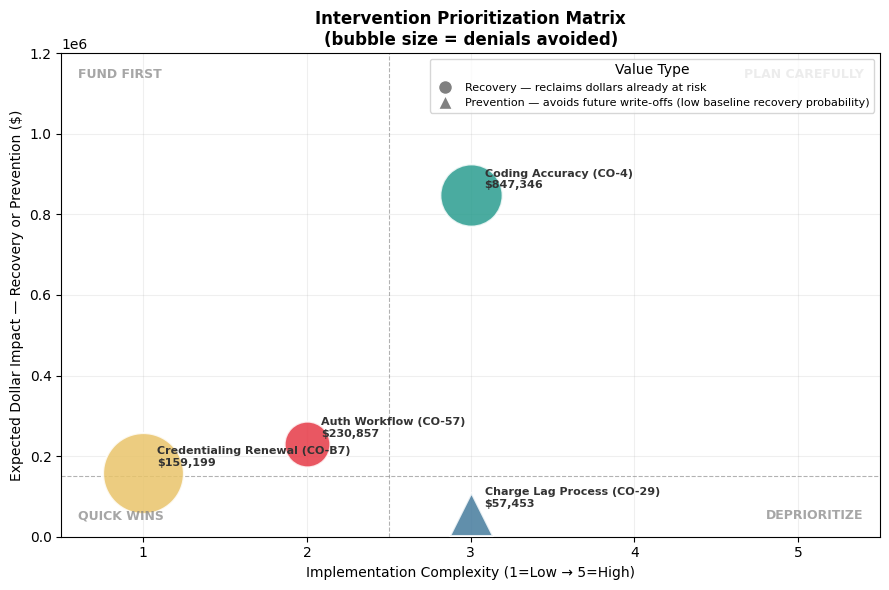

In [15]:
fig, ax = plt.subplots(figsize=(9, 6))

colors_map = {
    "Auth Workflow (CO-57)":         "#e63946",
    "Charge Lag Process (CO-29)":    "#457b9d",
    "Coding Accuracy (CO-4)":        "#2a9d8f",
    "Credentialing Renewal (CO-B7)": "#e9c46a",
}
value_type_map = {
    "Auth Workflow (CO-57)":         "Recovery",
    "Charge Lag Process (CO-29)":    "Prevention",
    "Coding Accuracy (CO-4)":        "Recovery",
    "Credentialing Renewal (CO-B7)": "Recovery",
}
marker_map = {"Recovery": "o", "Prevention": "^"}

for _, row in summary.iterrows():
    name   = row["intervention"]
    x      = row["complexity"]
    y      = row["dollars_recovered"]
    size   = max(100, row["denials_avoided"] * 3)
    color  = colors_map.get(name, "steelblue")
    vtype  = value_type_map.get(name, "Recovery")

    ax.scatter(x, y, s=size, color=color, marker=marker_map[vtype],
               alpha=0.85, edgecolors="white", linewidth=1.5, zorder=3)
    ax.annotate(
        f"{name}\n${y:,.0f}",
        (x, y), textcoords="offset points", xytext=(10, 5),
        fontsize=8, fontweight="bold", color="#333333"
    )

from matplotlib.lines import Line2D
type_legend = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10,
           label='Recovery — reclaims dollars already at risk'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='gray', markersize=10,
           label='Prevention — avoids future write-offs (low baseline recovery probability)'),
]
ax.legend(handles=type_legend, loc='upper right', fontsize=8, title="Value Type")

# Quadrant lines — fixed thresholds, not sample-dependent
mid_x = COMPLEXITY_THRESHOLD
mid_y = RECOVERY_THRESHOLD
ax.axvline(mid_x, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)
ax.axhline(mid_y, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)

# Headroom 
ax.set_ylim(0, summary["dollars_recovered"].max() * 1.18) # -- so the largest bubble + label isn't clipped

# Quadrant labels in fixed corners — independent of where bubbles land
ax.text(0.02, 0.97, "FUND FIRST", transform=ax.transAxes, fontsize=9,
        color="gray", fontweight="bold", alpha=0.7, va="top")
ax.text(0.98, 0.97, "PLAN CAREFULLY", transform=ax.transAxes, fontsize=9,
        color="gray", fontweight="bold", alpha=0.7, va="top", ha="right")
ax.text(0.02, 0.03, "QUICK WINS", transform=ax.transAxes, fontsize=9,
        color="gray", fontweight="bold", alpha=0.7, va="bottom")
ax.text(0.98, 0.03, "DEPRIORITIZE", transform=ax.transAxes, fontsize=9,
        color="gray", fontweight="bold", alpha=0.7, va="bottom", ha="right")

ax.set_xlabel("Implementation Complexity (1=Low → 5=High)", fontsize=10)
ax.set_ylabel("Expected Dollar Impact — Recovery or Prevention ($)", fontsize=10)
ax.set_title("Intervention Prioritization Matrix\n(bubble size = denials avoided)",
              fontsize=12, fontweight="bold")
ax.set_xlim(0.5, 5.5)
ax.set_ylim(0,1200000)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

In [16]:
# Export Cell for Intervention Matrix on Streamlit dashboard

# ── EXPORT: Intervention Matrix ─────────────────────────────────────────
from utils.export_helpers import validate_export, export_with_manifest_note

# value_type is in Cell 14's value_type_map — redefined here so this
# export cell doesn't depend on Cell 14 having run
value_type_map = {
    "Auth Workflow (CO-57)":          "Recovery",
    "Charge Lag Process (CO-29)":     "Prevention",
    "Coding Accuracy (CO-4)":         "Recovery",
    "Credentialing Renewal (CO-B7)":  "Recovery",
}

matrix_export = summary[[
    "intervention", "provider", "failure_node",
    "denials_avoided", "dollars_recovered", "complexity"
]].copy()
matrix_export["value_type"] = matrix_export["intervention"].map(value_type_map)

# Note: current_rate and target_rate columns in `summary` are formatted strings
# (e.g., "68%"). Not exported — display-only. The dashboard uses dollars_recovered
# and complexity as the two numeric axes; current/target rates belong in hover text
# if needed, and can be hardcoded in chart_builders.py for that panel.

validate_export(
    matrix_export,
    expected_columns=[
        "intervention", "provider", "failure_node",
        "denials_avoided", "dollars_recovered", "complexity", "value_type"
    ],
    grain_check_fn=lambda df: df["intervention"].is_unique,
    grain_description="one row per intervention",
    no_nulls_in=["intervention", "dollars_recovered", "complexity"],
)
export_with_manifest_note(
    matrix_export,
    output_path="../data/intervention_matrix.parquet",
    grain="One row per intervention (4 rows total)",
    source_notebook="05_intervention_modeling.ipynb",
)

Export validated: 4 rows, 7 columns

Written to: ../data/intervention_matrix.parquet
Paste/update this row in data/MANIFEST.md:

| `intervention_matrix.parquet` | One row per intervention (4 rows total) | 05_intervention_modeling.ipynb | 2026-06-19 | 4 rows |
